In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

In [22]:
fund = pd.read_csv("01_fund_master.csv")

nav = pd.read_csv("02_nav_history.csv")

benchmark = pd.read_csv("10_benchmark_indices.csv")

In [8]:
nav.columns = nav.columns.str.lower().str.strip()

benchmark.columns = benchmark.columns.str.lower().str.strip()

fund.columns = fund.columns.str.lower().str.strip()

nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

nav = nav.sort_values(["amfi_code","date"])

benchmark = benchmark.sort_values("date")

# This code cleans the data, converts dates into the correct format, and sorts the datasets so they are ready for analysis.

In [9]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


# The code calculates the daily percentage return for each mutual fund based on its NAV and provides summary statistics to understand the average return, risk (volatility), and the range of daily gains and losses.

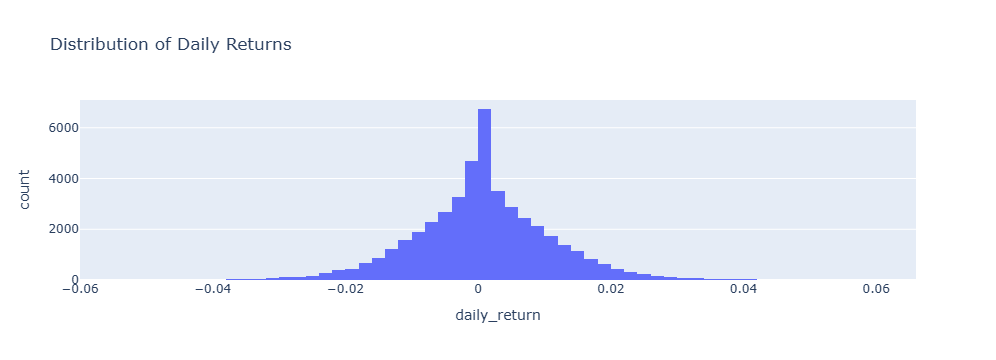

In [11]:
fig = px.histogram(
    nav,
    x="daily_return",
    nbins=100,
    title="Distribution of Daily Returns"
)

fig.show()

# Insights for the Histogram of Daily Returns
## Most daily returns are concentrated around 0%, indicating that mutual fund NAVs usually change only slightly from one day to the next.
## The histogram has a bell-shaped distribution, meaning most returns are close to the average, with fewer extreme gains or losses.
## There are very few large positive or negative returns, showing that significant daily price movements are uncommon.
## The distribution suggests stable and relatively low volatility, which is typical for diversified mutual funds.
## A small number of values in the tails represent rare market events that caused unusually high gains or losses.

# Conclusion:
## The daily returns are mostly small and centered around 0%, indicating that the mutual funds experienced generally stable day-to-day performance with only occasional large market movements.

# CAGR Function

In [14]:
def calculate_cagr(df, years):

    result=[]

    for code,data in df.groupby("amfi_code"):

        data=data.sort_values("date")

        end=data.iloc[-1]

        start_date=end["date"]-pd.DateOffset(years=years)

        start=data[data["date"]>=start_date]

        if len(start)==0:

            continue

        start=start.iloc[0]

        cagr=((end["nav"]/start["nav"])**(1/years))-1

        result.append([code,cagr])

    return pd.DataFrame(result,columns=["amfi_code",f"CAGR_{years}Y"])

##  This code calculates the Compound Annual Growth Rate (CAGR) for each mutual fund based on its NAV data. It first groups the data by AMFI code, sorts it by date, and finds the starting and ending NAV values for the selected number of years. Using these values, it calculates the average annual growth rate (CAGR) and stores the results in a new table with the AMFI code and CAGR. This helps compare the long-term performance of different mutual funds, where a higher CAGR indicates better growth over the selected period.

In [16]:
cagr1=calculate_cagr(nav,1)

cagr3=calculate_cagr(nav,3)

cagr5=calculate_cagr(nav,5)

cagr=cagr1.merge(cagr3,on="amfi_code",how="outer")

cagr=cagr.merge(cagr5,on="amfi_code",how="outer")

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


# This code calculates the **1-year, 3-year, and 5-year CAGR** for each mutual fund using the `calculate_cagr()` function. It then merges the three results into a single table based on the **AMFI code**, so that each fund has its 1-year, 3-year, and 5-year CAGR values in one place. Finally, `cagr.head()` displays the first five rows of the combined table, making it easy to compare the long-term performance of different mutual funds.


# Cell 6 : Sharpe Ratio

In [18]:
RF=0.065

sharpe=[]

for code,data in nav.groupby("amfi_code"):

    r=data["daily_return"].dropna()

    if len(r)<2:

        continue

    annual_return=r.mean()*252

    annual_std=r.std()*np.sqrt(252)

    ratio=(annual_return-RF)/annual_std

    sharpe.append([code,ratio])

sharpe=pd.DataFrame(sharpe,columns=["amfi_code","Sharpe"])

sharpe.sort_values("Sharpe",ascending=False).head()

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


## This code calculates the **Sharpe Ratio** for each mutual fund to measure its **risk-adjusted performance**. It groups the data by **AMFI code**, calculates the annual return and annual risk (standard deviation) from daily returns, and then computes the Sharpe Ratio using a risk-free rate of **6.5%**. The results are stored in a new DataFrame, sorted in descending order, and the top-performing funds with the highest Sharpe Ratios are displayed. A **higher Sharpe Ratio** indicates that a fund has generated better returns for the level of risk it has taken.


# Cell 7 : Sortino Ratio

In [20]:
sortino=[]

for code,data in nav.groupby("amfi_code"):

    r=data["daily_return"].dropna()

    downside=r[r<0]

    if len(downside)<2:

        continue

    downside_std=downside.std()*np.sqrt(252)

    annual_return=r.mean()*252

    ratio=(annual_return-RF)/downside_std

    sortino.append([code,ratio])

sortino=pd.DataFrame(sortino,columns=["amfi_code","Sortino"])

sortino.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


## This code calculates the Sortino Ratio for each mutual fund to measure its risk-adjusted performance by considering only downside risk. It groups the data by AMFI code, selects only the negative daily returns, calculates the downside risk and annual return, and then computes the Sortino Ratio using a risk-free rate of 6.5%. The results are stored in a new DataFrame, and sortino.head() displays the first five funds. A higher Sortino Ratio indicates that a fund has generated better returns while minimizing downside risk.

# Cell 8 : Prepare Benchmark

In [24]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [26]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

## The code `benchmark.head()` displays the **first five rows** of the `benchmark` DataFrame. It is used to quickly check whether the benchmark dataset has been loaded correctly, verify the column names and data types, and inspect the sample values before performing further analysis or calculations.


# Cell 9 : Alpha Beta

In [35]:
# Check the columns in nav

In [37]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [38]:
# Create the daily return again

In [40]:
# Sort the data
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Check
print(nav[["amfi_code", "date", "nav", "daily_return"]].head())

      amfi_code        date       nav  daily_return
5750     100016  2022-01-03  520.4608           NaN
5751     100016  2022-01-04  515.0971     -0.010306
5752     100016  2022-01-05  521.7239      0.012865
5753     100016  2022-01-06  515.7880     -0.011377
5754     100016  2022-01-07  515.1639     -0.001210


## This code first sorts the mutual fund data by **AMFI code** and **date** to ensure the records are in chronological order. It then calculates the **daily percentage return** for each mutual fund using the NAV values and stores the result in a new column called `daily_return`. Finally, it displays the first five rows with the AMFI code, date, NAV, and daily return to verify that the calculations have been performed correctly.


In [41]:
# Verify it exists

In [43]:
print("daily_return" in nav.columns)

True


In [44]:
# Then run Alpha-Beta

In [53]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# Convert date
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort by date
benchmark = benchmark.sort_values("date")

# Find the benchmark value column automatically
numeric_cols = benchmark.select_dtypes(include=np.number).columns.tolist()

# Remove benchmark_return if it already exists
numeric_cols = [c for c in numeric_cols if c != "benchmark_return"]

if len(numeric_cols) == 0:
    raise ValueError("No numeric benchmark column found.")

benchmark_col = numeric_cols[0]

print("Using benchmark column:", benchmark_col)

# Create benchmark returns
benchmark["benchmark_return"] = benchmark[benchmark_col].pct_change()

Using benchmark column: close_value


In [54]:
# Make sure fund daily returns exist

In [56]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Alpha & Beta Calculation

In [59]:
alpha_beta = []

for code, data in nav.groupby("amfi_code"):

    merged = pd.merge(
        data[["date", "daily_return"]],
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if merged.empty or len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta)

print(alpha_beta.head())

   amfi_code     Alpha          Beta
0     100016  0.047396 -1.990801e-05
1     100025  0.046067 -5.461978e-06
2     100033  0.251244  3.546602e-05
3     101206  0.214153  8.384919e-07
4     101207  0.119097 -2.062609e-05


In [61]:
print(nav.columns.tolist())
print(benchmark.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']
['date', 'index_name', 'close_value', 'benchmark_return']


In [63]:
drawdown=[]

for code,data in nav.groupby("amfi_code"):

    data=data.sort_values("date").copy()

    data["running_max"]=data["nav"].cummax()

    data["drawdown"]=data["nav"]/data["running_max"]-1

    idx=data["drawdown"].idxmin()

    worst=data.loc[idx]

    drawdown.append([

        code,

        worst["drawdown"],

        worst["date"]

    ])

drawdown=pd.DataFrame(

    drawdown,

    columns=[

        "amfi_code",

        "Max_Drawdown",

        "Worst_Date"

    ]

)

drawdown.head()

,amfi_code,Max_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


# Cell 11 : Fund Scorecard

In [66]:
score=cagr.merge(sharpe,on="amfi_code")

score=score.merge(alpha_beta,on="amfi_code")

score=score.merge(drawdown,on="amfi_code")

In [68]:
fund.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [71]:
print(fund.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [74]:
# Merge expense ratio
score = score.merge(
    fund[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

# Create ranks
score["return_rank"] = score["CAGR_3Y"].rank(ascending=False)
score["sharpe_rank"] = score["Sharpe"].rank(ascending=False)
score["alpha_rank"] = score["Alpha"].rank(ascending=False)

# Lower expense ratio is better
score["expense_rank"] = score["expense_ratio_pct"].rank(ascending=True)

# Smaller drawdown (less negative) is better
score["dd_rank"] = score["Max_Drawdown"].rank(ascending=False)

# Composite Score
score["Fund_Score"] = (
      0.30 * score["return_rank"]
    + 0.25 * score["sharpe_rank"]
    + 0.20 * score["alpha_rank"]
    + 0.15 * score["expense_rank"]
    + 0.10 * score["dd_rank"]
)

# Normalize to 0-100
score["Fund_Score"] = (
    score["Fund_Score"] / score["Fund_Score"].max()
) * 100

# Sort
score = score.sort_values("Fund_Score", ascending=False)

# Display top funds
print(score.head())

# Save CSV
score.to_csv("fund_scorecard.csv", index=False)

   amfi_code   CAGR_1Y   CAGR_3Y   CAGR_5Y    Sharpe     Alpha      Beta  \
0     102886 -0.167975 -0.007674  0.010303 -0.205832  0.032480 -0.000008   
1     100016 -0.022243  0.012926  0.023168 -0.201517  0.047396 -0.000020   
2     119095 -0.427976 -0.117058  0.013376 -0.075974  0.077458 -0.000054   
3     101207 -0.239860 -0.041524  0.069533  0.162661  0.119097 -0.000021   
4     119092  0.016091  0.005259  0.055826  0.030785  0.070787 -0.000003   

   Max_Drawdown Worst_Date  expense_ratio_pct_x  return_rank  sharpe_rank  \
0     -0.280011 2026-04-27                 1.51         37.0         36.0   
1     -0.247344 2022-09-15                 1.55         35.0         35.0   
2     -0.516778 2026-05-11                 1.38         40.0         33.0   
3     -0.354469 2026-05-11                 1.53         39.0         28.0   
4     -0.144016 2025-02-07                 1.64         36.0         31.0   

   alpha_rank  expense_rank  dd_rank  Fund_Score  expense_ratio_pct_y  \
0      

## This code creates a **mutual fund scorecard** by combining multiple performance metrics into a single **Fund Score**. It first merges the expense ratio with the performance data, then ranks each fund based on **3-year CAGR, Sharpe Ratio, Alpha, Expense Ratio, and Maximum Drawdown**. These ranks are combined using weighted scores to calculate an overall Fund Score, which is normalized to a scale of **0–100**. Finally, the funds are sorted by their Fund Score, the top-performing funds are displayed, and the complete scorecard is saved as **`fund_scorecard.csv`** for further analysis.


# Cell 12 : Tracking Error

In [76]:
tracking=[]

for code,data in nav.groupby("amfi_code"):

    merged=pd.merge(

        data[["date","daily_return"]],

        benchmark[["date","benchmark_return"]],

        on="date"

    ).dropna()

    if len(merged)<30:

        continue

    te=np.std(

        merged["daily_return"]-

        merged["benchmark_return"]

    )*np.sqrt(252)

    tracking.append([code,te])

tracking=pd.DataFrame(

    tracking,

    columns=["amfi_code","Tracking_Error"]

)

tracking.head()

,amfi_code,Tracking_Error
0,100016,82.158937
1,100025,82.157631
2,100033,82.154477
3,101206,82.157233
4,101207,82.159272


## This code calculates the **Tracking Error** for each mutual fund by comparing its daily returns with the benchmark's daily returns. It first merges the fund and benchmark data based on the **date**, then calculates the difference between their daily returns. The standard deviation of these differences is annualized to obtain the **Tracking Error**. The results are stored in a new DataFrame with the **AMFI code** and **Tracking Error**, and `tracking.head()` displays the first five funds. A **lower Tracking Error** indicates that the fund closely follows the benchmark, while a **higher Tracking Error** means its performance deviates more from the benchmark.


# Cell 13 : Benchmark Comparison

In [78]:
top5=score.head(5)["amfi_code"]

In [81]:
benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [83]:
import numpy as np

# Convert date
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort by date
benchmark = benchmark.sort_values("date")

# Find numeric columns except benchmark_return
value_cols = benchmark.select_dtypes(include=np.number).columns.tolist()

if "benchmark_return" in value_cols:
    value_cols.remove("benchmark_return")

print("Benchmark Value Columns:", value_cols)

benchmark_value_col = value_cols[0]

print("Using:", benchmark_value_col)

Benchmark Value Columns: ['close_value']
Using: close_value


Available Benchmarks:
['NIFTY50' 'CRISIL_LIQUID' 'NIFTY_MIDCAP150' 'CRISIL_GILT' 'NIFTY100'
 'NIFTY500' 'BSE_SMALLCAP']
Using Benchmark: NIFTY50


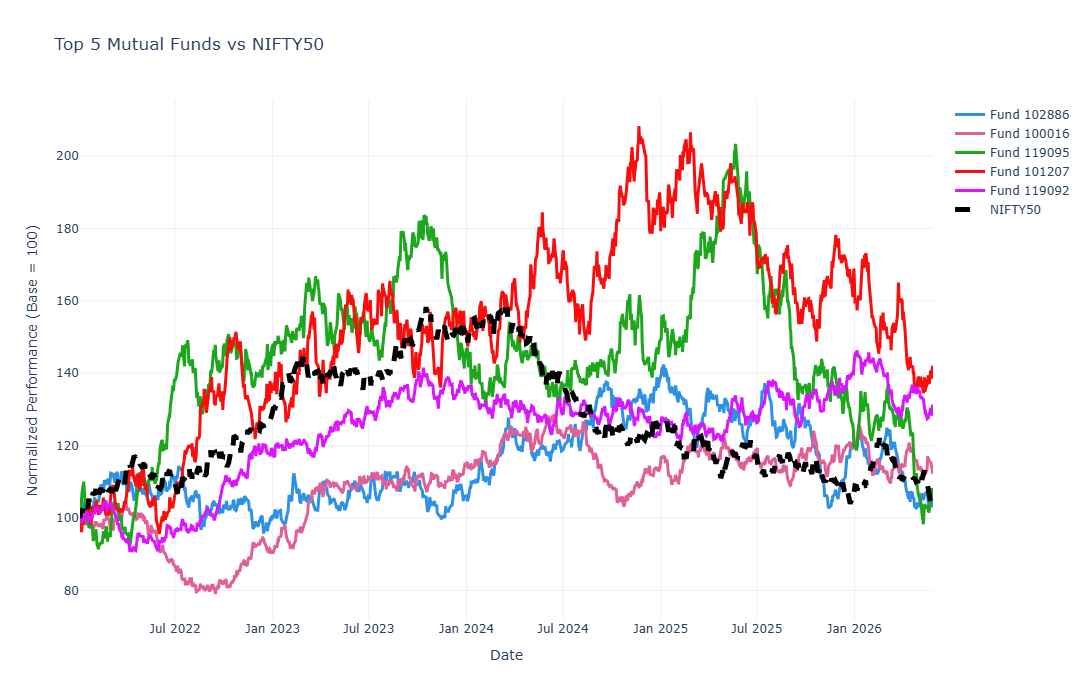

In [105]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Top 5 Funds
top5 = score.sort_values("Fund_Score", ascending=False)["amfi_code"].head(5)

# ---------------- Benchmark ----------------

# Display available benchmark names
print("Available Benchmarks:")
print(benchmark["index_name"].unique())

# Automatically choose the first benchmark
benchmark_name = benchmark["index_name"].dropna().unique()[0]

print("Using Benchmark:", benchmark_name)

benchmark_plot = benchmark[
    benchmark["index_name"] == benchmark_name
].copy()

benchmark_plot = benchmark_plot.sort_values("date")

# Normalize benchmark
benchmark_plot["Normalized"] = (
    benchmark_plot["close_value"] /
    benchmark_plot["close_value"].iloc[0]
) * 100

# ---------------- Plot ----------------

fig = go.Figure()

colors = px.colors.qualitative.Dark24

# Plot Top 5 Funds
for i, code in enumerate(top5):

    df = nav[nav["amfi_code"] == code].sort_values("date").copy()

    if df.empty:
        continue

    df["Normalized"] = (
        df["nav"] /
        df["nav"].iloc[0]
    ) * 100

    fig.add_trace(
        go.Scatter(
            x=df["date"],
            y=df["Normalized"],
            mode="lines",
            name=f"Fund {code}",
            line=dict(
                color=colors[i % len(colors)],
                width=3
            )
        )
    )

# Plot Benchmark
fig.add_trace(
    go.Scatter(
        x=benchmark_plot["date"],
        y=benchmark_plot["Normalized"],
        mode="lines",
        name=benchmark_name,
        line=dict(
            color="black",
            width=5,
            dash="dash"
        )
    )
)

fig.update_layout(
    title=f"Top 5 Mutual Funds vs {benchmark_name}",
    xaxis_title="Date",
    yaxis_title="Normalized Performance (Base = 100)",
    template="plotly_white",
    hovermode="x unified",
    width=1400,
    height=700
)

fig.show()

## This code compares the **top 5 mutual funds** with a **benchmark index** by plotting their performance over time. It first converts the date columns into datetime format, selects the top five funds based on the **Fund Score**, and chooses a benchmark index. The NAV values of each fund and the benchmark index are **normalized to a base value of 100** so their performance can be compared on the same scale. Finally, it creates an interactive line chart showing how each top fund has performed relative to the benchmark over time.


In [102]:
print(nav.columns.tolist())

print(benchmark.columns.tolist())

print(score.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']
['date', 'index_name', 'close_value', 'benchmark_return']
['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'Sharpe', 'Alpha', 'Beta', 'Max_Drawdown', 'Worst_Date', 'expense_ratio_pct_x', 'return_rank', 'sharpe_rank', 'alpha_rank', 'expense_rank', 'dd_rank', 'Fund_Score', 'expense_ratio_pct_y', 'expense_ratio_pct']


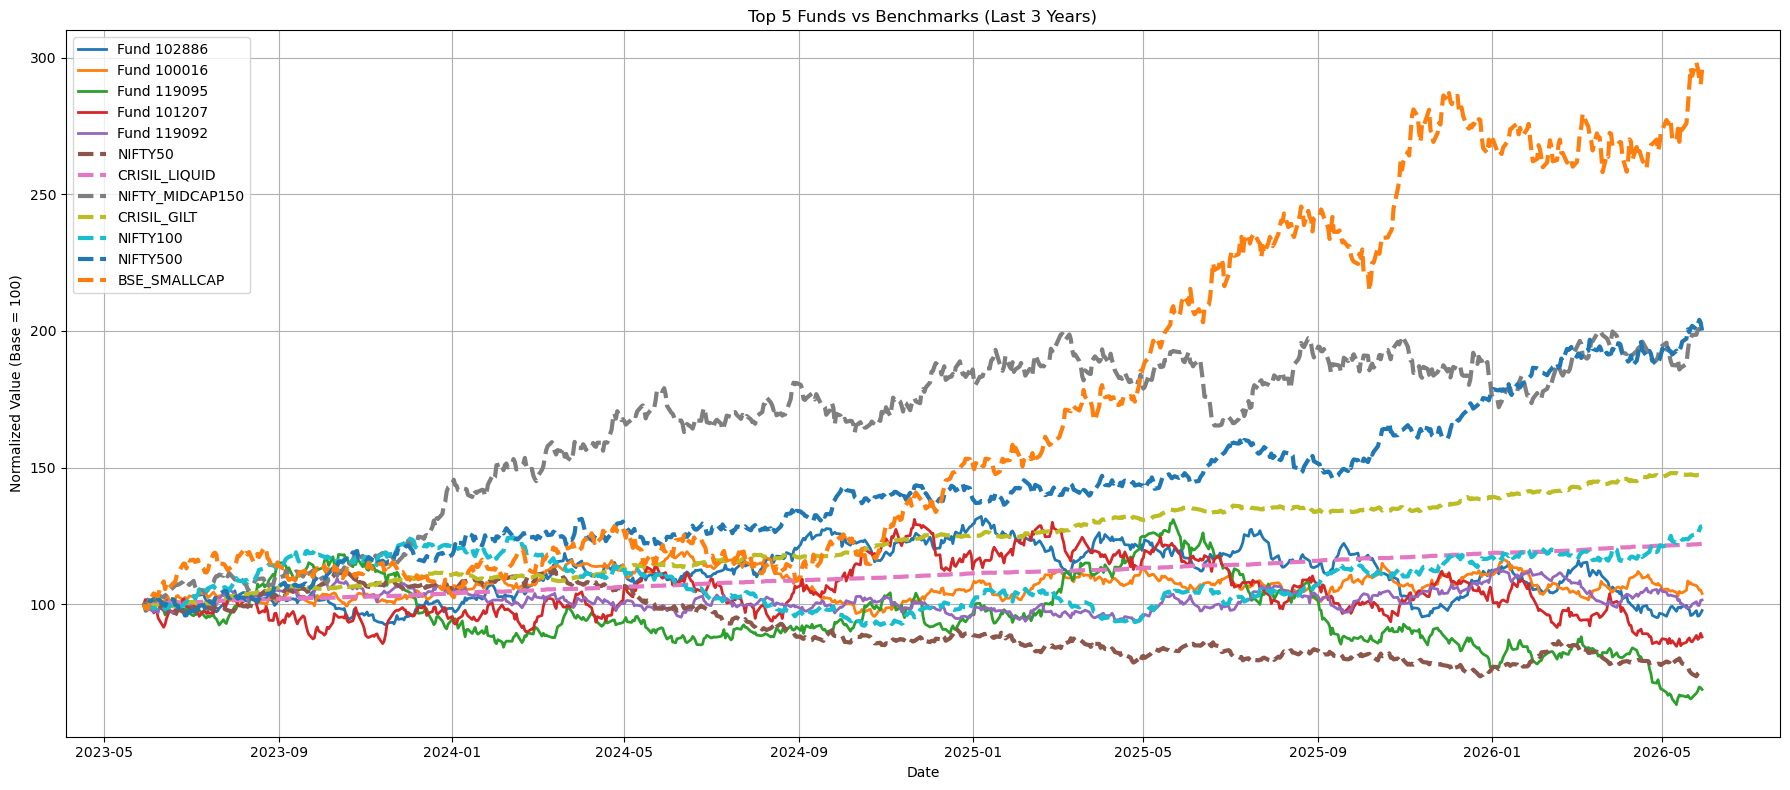

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Last 3 years
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

# Top 5 Funds
top5 = score.sort_values("Fund_Score", ascending=False)["amfi_code"].head(5)

plt.figure(figsize=(18,8))

# Plot Funds
for code in top5:

    df = nav[
        (nav["amfi_code"] == code) &
        (nav["date"] >= start_date)
    ].sort_values("date")

    df = df.copy()

    df["Normalized"] = (
        df["nav"] /
        df["nav"].iloc[0]
    ) * 100

    plt.plot(
        df["date"],
        df["Normalized"],
        linewidth=2,
        label=f"Fund {code}"
    )

# Plot each benchmark separately
for index_name in benchmark["index_name"].unique():

    b = benchmark[
        (benchmark["index_name"] == index_name) &
        (benchmark["date"] >= start_date)
    ].sort_values("date")

    if b.empty:
        continue

    b = b.copy()

    b["Normalized"] = (
        b["close_value"] /
        b["close_value"].iloc[0]
    ) * 100

    plt.plot(
        b["date"],
        b["Normalized"],
        linewidth=3,
        linestyle="--",
        label=index_name
    )

plt.title("Top 5 Funds vs Benchmarks (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "benchmark_comparison.png",
    dpi=400
)

plt.show()

## This code compares the **top 5 mutual funds** with all available **benchmark indices** over the **last three years**. It first converts the date columns to datetime format, filters the data for the last three years, and normalizes the NAV and benchmark values to a base value of **100** so they can be compared fairly. It then plots the fund performance as solid lines and the benchmark indices as dashed lines on the same chart. Finally, the chart is saved as **`benchmark_comparison.png`** and displayed, making it easy to compare how the top-performing funds have performed against the benchmarks over time.


In [108]:
import numpy as np

tracking_error = []

# Use NIFTY 100 benchmark (change the name if needed)
benchmark_100 = benchmark[
    benchmark["index_name"] == benchmark["index_name"].unique()[0]
].copy()

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        benchmark_100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    te = np.std(
        merged["daily_return"] -
        merged["benchmark_return"]
    ) * np.sqrt(252)

    tracking_error.append([code, te])

tracking_error = pd.DataFrame(
    tracking_error,
    columns=["amfi_code", "Tracking_Error"]
)

tracking_error.sort_values(
    "Tracking_Error",
    inplace=True
)

tracking_error.head()

,amfi_code,Tracking_Error
2,100033,77.776909
16,119094,77.777816
8,102887,77.777844
21,119598,77.778466
28,120841,77.779023


## This code calculates the **Tracking Error** for each mutual fund by comparing its daily returns with a selected benchmark index. It first selects one benchmark, merges the fund and benchmark data using the **date** column, and calculates the difference between their daily returns. The standard deviation of these differences is annualized to obtain the **Tracking Error**. The results are stored in a new DataFrame, sorted in ascending order, and the funds with the **lowest Tracking Error** are displayed. A lower Tracking Error means the fund's performance closely follows the benchmark.


In [109]:
score.to_csv("fund_scorecard.csv", index=False)

alpha_beta.to_csv("alpha_beta.csv", index=False)

tracking_error.to_csv("tracking_error.csv", index=False)